# Context-Update Gain Diagnostics

## Why $\|c\|$ after update is uninformative

The model uses a **norm-preserving** context update. Let
$$
\hat c_{in} \;=\; \frac{M_{FC}f}{\|M_{FC}f\|},
\qquad
d \;=\; c^\top \hat c_{in}.
$$

Then the updated context is
$$
c^{+} \;=\; \rho\,c + B_{rec}\,\hat c_{in},
\qquad
\rho \;=\; \sqrt{1 + B_{rec}^{2}(d^{2}-1)} \;-\; B_{rec}\,d,
$$
which enforces $\|c^{+}\|=1$ (up to floating-point noise).  
So logging $\|c^{+}\|$ is expected to produce a flat line.

## What *is* informative

Two quantities capture **gain** and **input strength**:

| Symbol | Definition | Interpretation |
|---|---|---|
| $\|c^\star\|$ | $\|(1-B_{rec})c + B_{rec}\hat c_{in}\|$ | **Update gain** (pre-normalization mixture magnitude); depends on $B_{rec}$ and $d=\cos(c,\hat c_{in})$. |
| $\|c^{raw}_{in}\|$ | $\|M_{FC}f\|$ | **Context-input strength** before normalization; tends to vary with $\gamma_{fc}$ and encoding-scale parameters. |

### Per-parameter expectations

| Parameter | $\|c^{\star}\|$ informative? | $\|c_{in}^{\text{raw}}\|$ informative? | $\cos(c,\hat{c}_{in})$ informative? |
|-----------|-----|-----|-----|
| $B_{rec}$ | Yes: changes mixture weights directly | moderate | Yes: alignment under varying drift |
| $\gamma_{fc}$ | moderate | Yes: directly scales $M_{FC}$ | Yes: stronger input != better aligned |
| $\eta$ | weak (noise affects competition, not context) | weak | Yes: which item wins changes alignment |
| $B_{enc}$ scale | moderate | Yes: scales learned weights | Yes: stronger != more targeted |

---

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
warnings.filterwarnings('ignore')

from cmr.config import (
    N, pres_indices, BASE_PARAMS, B_encD,
    episodic_weight, sem_weight, sem_mat,
    lrate_cf_enc, lrate_fc_rec, lrate_cf_rec,
    thresh, rec_time, dt, tau, K, L,
    B_rec_grid, gamma_fc_grid, eta_grid, B_encD_scale_grid,
    n_sims,
)
from cmr.visualization import make_sweep_colors, _add_colorbar, line_with_colored_points

### Simulation function

Variant of `simulate_single_trial` that logs two quantities per recall step:

* $\|c_{in}^{\text{raw}}\| = \|M_{FC}\,f\|$ before normalization
* $\|c^{\star}\| = \|(1-B_{rec})\,c + B_{rec}\,\hat{c}_{in}\|$ (update gain)
* $\cos(c^{+}, \hat{c}_{in})$ after update
    > “how aligned are we after the update step?”
* $c^{\top}\hat{c}_{in}$ before update
    > “how aligned were we before incorporating this cue?”

In [2]:
def _dot(a, b):
    return float(np.asarray(a.T @ b).ravel()[0])

def _norm(v):
    return float(np.linalg.norm(v))


def simulate_context_gain_diagnostics(
    B_rec, rng,
    gamma_fc_val=None, eta_val=None, B_encD_scale=1.0,
):
    """
    One CMR trial returning per-recall-step context-update diagnostics.

    Returns
    -------
    traces : dict with keys
        "c_in_raw_norm"  : list[float]  -- ||M_FC * f|| before normalization
        "c_star_norm"    : list[float]  -- ||(1-B_rec)*c + B_rec*c_in_hat||
        "cos_c_cin"      : list[float]  -- cos(c+, c_in_hat) after update
        "dot_before"     : list[float]  -- c^T c_in_hat before update
    """
    if gamma_fc_val is None:
        gamma_fc_val = BASE_PARAMS["gamma_fc"]
    if eta_val is None:
        eta_val = BASE_PARAMS["eta"]

    eye_fc = 1.0 - gamma_fc_val
    lrate_fc_enc = gamma_fc_val
    B_encD_local = B_encD * B_encD_scale

    # -- Encoding --
    net_f = np.zeros((N, 1))
    net_c = np.zeros((N, 1))
    net_w_fc = np.eye(N) * eye_fc
    net_w_cf = np.eye(N) * 0.0

    for item_idx in range(N):
        fidx = int(pres_indices[item_idx] - 1)
        net_f[:] = 0; net_f[fidx] = 1

        c_in_raw = net_w_fc @ net_f
        c_in_hat = c_in_raw / _norm(c_in_raw)

        B = float(B_encD_local[item_idx])
        d = _dot(net_c, c_in_hat)
        rad = 1.0 + B**2 * (d**2 - 1.0)
        rho = np.sqrt(rad) - B * d
        net_c = rho * net_c + B * c_in_hat

        net_w_fc += (net_c @ net_f.T) * lrate_fc_enc
        net_w_cf += (net_f @ net_c.T) * lrate_cf_enc

    # -- Retrieval --
    retrieved = np.zeros((N, 1), dtype=bool)
    thresholds = np.ones((N, 1))
    net_weights = episodic_weight * net_w_cf + sem_weight * sem_mat

    traces = {"c_in_raw_norm": [], "c_star_norm": [],
             "cos_c_cin": [], "dot_before": []}

    time_passed = 0.0
    dt_tau = dt / tau
    sq_dt_tau = np.sqrt(dt_tau)
    inds = np.arange(N)
    eyeI = ~np.eye(N, dtype=bool)
    lmat = eyeI.astype(float) * L

    while time_passed < rec_time:
        f_in = net_weights @ net_c

        max_cycles = int((rec_time - time_passed) / dt)
        noise = rng.normal(0, eta_val * sq_dt_tau, size=(N, max_cycles))
        x = np.zeros((N, 1))
        K_arr = np.ones((N, 1)) * K

        crossed = 0; i = 0
        while i < max_cycles and crossed == 0:
            lx = lmat @ x; kx = K_arr * x
            x = x + ((f_in - kx - lx) * dt_tau + noise[:, i:i+1])
            x[x < 0] = 0
            reset = retrieved & (x >= thresholds)
            x[reset] = 0.95 * thresholds[reset]
            retrievable = ~retrieved
            if np.any(x[retrievable] >= thresholds[retrievable]):
                crossed = 1
                tw = x[retrievable] >= thresholds[retrievable]
                ti = inds[retrievable.flatten()]
                winners = ti[tw.flatten()]
                if len(winners) > 1:
                    winners = np.array([rng.choice(winners)])
            i += 1
        time_passed += i * dt

        if crossed == 1:
            winner = int(winners[0])
            net_f[:] = 0; net_f[winner] = 1

            # Raw context input (before normalization)
            c_in_raw = net_w_fc @ net_f
            c_in_raw_norm = _norm(c_in_raw)
            c_in_hat = c_in_raw / c_in_raw_norm if c_in_raw_norm > 1e-15 else c_in_raw

            # Dot product c^T c_in_hat (before update)
            dot_val = _dot(net_c, c_in_hat)

            # Naive linear mixture magnitude (update gain)
            c_star = (1.0 - B_rec) * net_c + B_rec * c_in_hat
            c_star_norm = _norm(c_star)

            # Actual norm-preserving update
            rad_val = 1.0 + B_rec**2 * (dot_val**2 - 1.0)
            rho_val = np.sqrt(rad_val) - B_rec * dot_val
            net_c = rho_val * net_c + B_rec * c_in_hat

            # cos(c+, c_in_hat) after update
            cn = _norm(net_c)
            cos_val = _dot(net_c, c_in_hat) / cn if cn > 1e-15 else np.nan

            traces["c_in_raw_norm"].append(c_in_raw_norm)
            traces["c_star_norm"].append(c_star_norm)
            traces["cos_c_cin"].append(cos_val)
            traces["dot_before"].append(dot_val)

            net_w_fc += (net_c @ net_f.T) * lrate_fc_rec
            net_w_cf += (net_f @ net_c.T) * lrate_cf_rec
            retrieved[winner] = True

    return traces

### Batch runner

In [3]:
def run_context_gain_sweep(param_name, param_grid, n_sims=200, base_seed=2026):
    """Run context-gain diagnostics across a parameter grid."""
    results = {}

    for idx, val in enumerate(param_grid):
        params = BASE_PARAMS.copy()
        params[param_name] = float(val)
        rng = np.random.default_rng(base_seed + idx)

        all_traces = []
        for _ in range(n_sims):
            tr = simulate_context_gain_diagnostics(
                B_rec=params["B_rec"], rng=rng,
                gamma_fc_val=params["gamma_fc"],
                eta_val=params["eta"],
                B_encD_scale=params["B_encD_scale"],
            )
            all_traces.append(tr)

        entry = {}
        for field in ["c_in_raw_norm", "c_star_norm", "cos_c_cin", "dot_before"]:
            lens = [len(t[field]) for t in all_traces if t[field]]
            if not lens:
                entry[field] = (np.array([]), np.array([]))
                continue
            T = max(lens)
            M = np.full((len(all_traces), T), np.nan)
            for i, t in enumerate(all_traces):
                arr = np.array(t[field], dtype=float)
                M[i, :len(arr)] = arr
            entry[field] = (np.arange(1, T + 1), np.nanmean(M, axis=0))

        results[val] = entry
        print(f"  {param_name}={val:.4g}  done")

    return results

### Plotting helper

In [27]:
def plot_context_gain_panel(results, param_grid, field, param_label,
                          title, ylabel, ref_line=None,
                          cmap_name="viridis", figsize=(8, 4.5)):
    """Plot one diagnostic field across a parameter sweep."""
    param_grid = np.asarray(param_grid, dtype=float)
    colors, norm, cmap = make_sweep_colors(param_grid, cmap_name)

    fig, ax = plt.subplots(figsize=figsize)
    for val, c in zip(param_grid, colors):
        x, y = results[val][field]
        if x.size:
            ax.plot(x, y, marker="o", color=c, ms=4, lw=1.2)
    if ref_line is not None:
        ax.axhline(ref_line, ls="--", color="gray", alpha=0.6)
    ax.set_title(title)
    ax.set_xlabel("recall step")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)
    _add_colorbar(fig, ax, norm, cmap, param_label)
    fig.tight_layout()
    plt.show()

---
## 1. Sweep $B_{rec}$ (retrieval context update strength)

$B_{rec}$ directly controls the mixture weights $(1-B_{rec})$ and $B_{rec}$,
so $\|c^{\star}\|$ is **guaranteed to change** -- it reflects the update gain
under different drift rates.

$\cos(c, \hat{c}_{in})$ tells you whether the retrieved item's context input
is aligned with the current context; this determines how much new information
each update injects.

In [5]:
cg_B_rec = run_context_gain_sweep("B_rec", B_rec_grid, n_sims=n_sims)

  B_rec=0.2  done
  B_rec=0.4  done
  B_rec=0.6  done
  B_rec=0.8  done
  B_rec=1  done
  B_rec=1.2  done


### $\|c_{in}^{\text{raw}}\|$ raw context-input strength

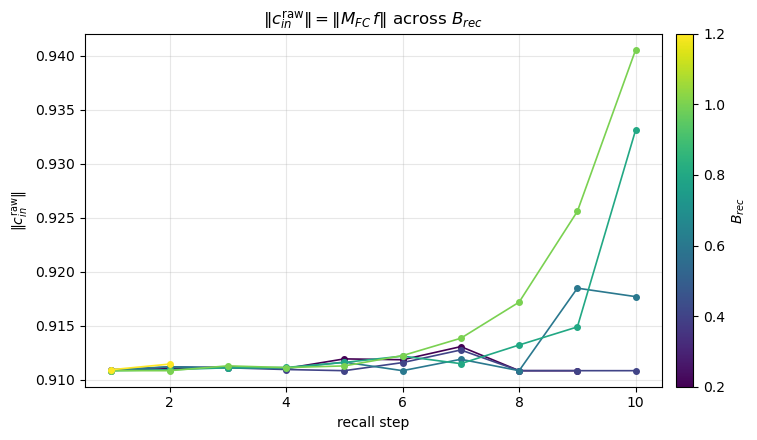

In [6]:
plot_context_gain_panel(
    cg_B_rec, B_rec_grid, "c_in_raw_norm", r"$B_{rec}$",
    title=r"$\|c_{in}^{\mathrm{raw}}\| = \|M_{FC}\,f\|$ across $B_{rec}$",
    ylabel=r"$\|c_{in}^{\mathrm{raw}}\|$")

### $\|c^{\star}\|$ pre-normalization update gain

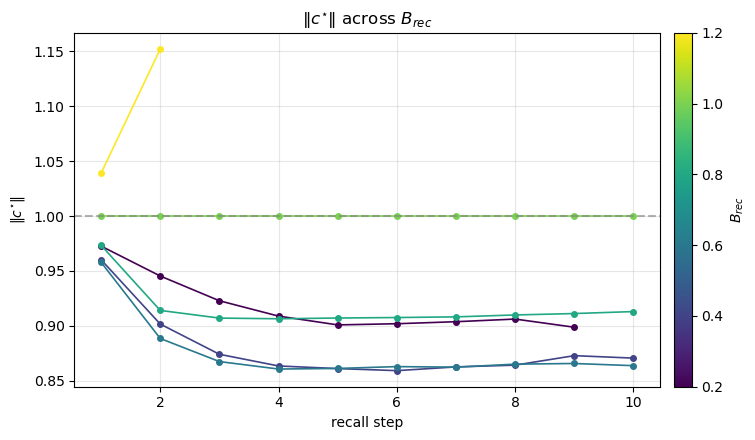

In [7]:
plot_context_gain_panel(
    cg_B_rec, B_rec_grid, "c_star_norm", r"$B_{rec}$",
    title=r"$\|c^{\star}\|$ across $B_{rec}$",
    ylabel=r"$\|c^{\star}\|$", ref_line=1.0)

### $\cos(c^{+}, \hat{c}_{in})$ post-update alignment

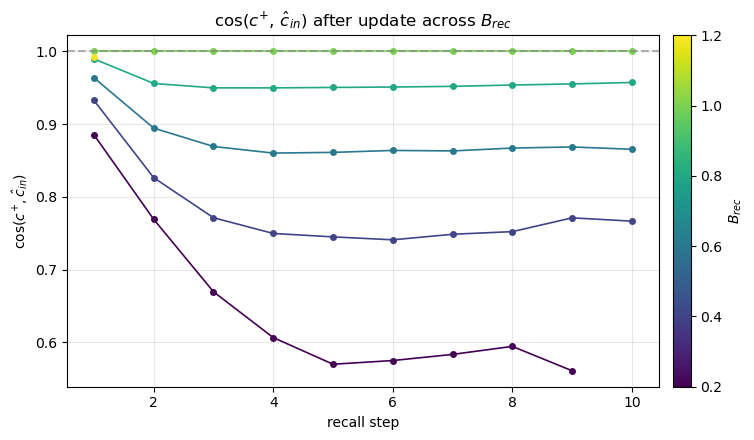

In [8]:
plot_context_gain_panel(
    cg_B_rec, B_rec_grid, "cos_c_cin", r"$B_{rec}$",
    title=r"$\cos(c^{+},\,\hat{c}_{in})$ after update across $B_{rec}$",
    ylabel=r"$\cos(c^{+}, \hat{c}_{in})$", ref_line=1.0)

### $c^{\top}\hat{c}_{in}$ pre-update alignment

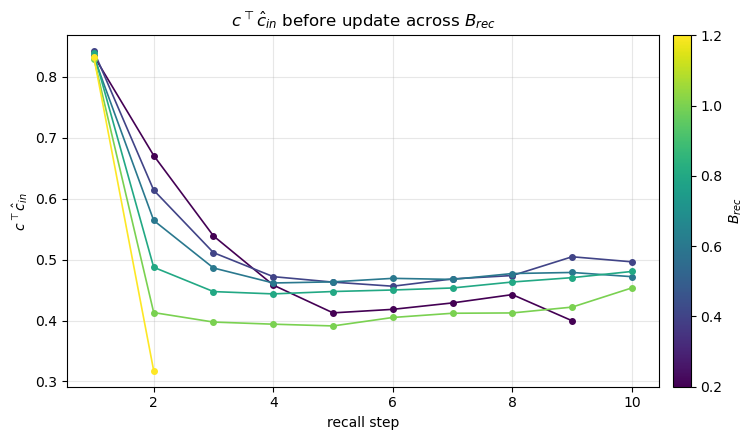

In [9]:
plot_context_gain_panel(
    cg_B_rec, B_rec_grid, "dot_before", r"$B_{rec}$",
    title=r"$c^{\top}\hat{c}_{in}$ before update across $B_{rec}$",
    ylabel=r"$c^{\top}\hat{c}_{in}$")

---
## 2. Sweep $\gamma_{fc}$ (feature-to-context association strength)

$\gamma_{fc}$ controls how much learned structure is written into $M_{FC}$
during encoding.  This directly scales $\|c_{in}^{\text{raw}}\| = \|M_{FC}\,f\|$:
stronger associations produce larger raw context inputs.

The key question: does a stronger $\|c_{in}^{\text{raw}}\|$ also produce
a better-**aligned** $\hat{c}_{in}$, or is the extra magnitude diffuse?
Compare $\|c_{in}^{\text{raw}}\|$ vs $\cos(c, \hat{c}_{in})$ to answer this.

In [10]:
cg_gamma_fc = run_context_gain_sweep("gamma_fc", gamma_fc_grid, n_sims=n_sims)

  gamma_fc=0.2  done
  gamma_fc=0.3  done
  gamma_fc=0.4  done
  gamma_fc=0.5  done
  gamma_fc=0.6  done
  gamma_fc=0.7  done
  gamma_fc=0.8  done


### $\|c_{in}^{\text{raw}}\|$ raw context-input strength

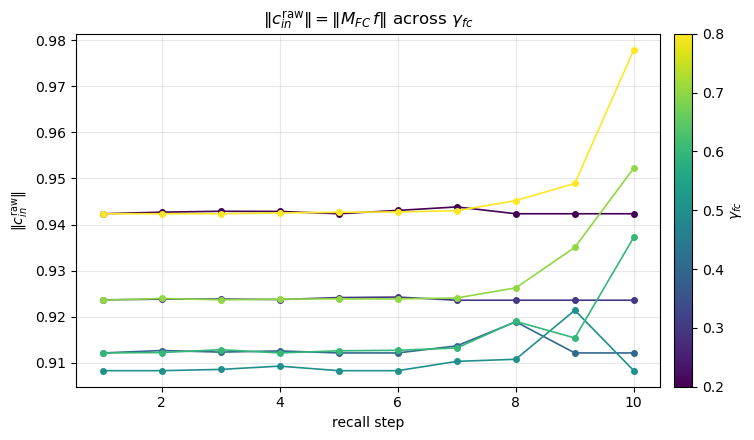

In [11]:
plot_context_gain_panel(
    cg_gamma_fc, gamma_fc_grid, "c_in_raw_norm", r"$\gamma_{fc}$",
    title=r"$\|c_{in}^{\mathrm{raw}}\| = \|M_{FC}\,f\|$ across $\gamma_{fc}$",
    ylabel=r"$\|c_{in}^{\mathrm{raw}}\|$")

### $\|c^{\star}\|$ pre-normalization update gain

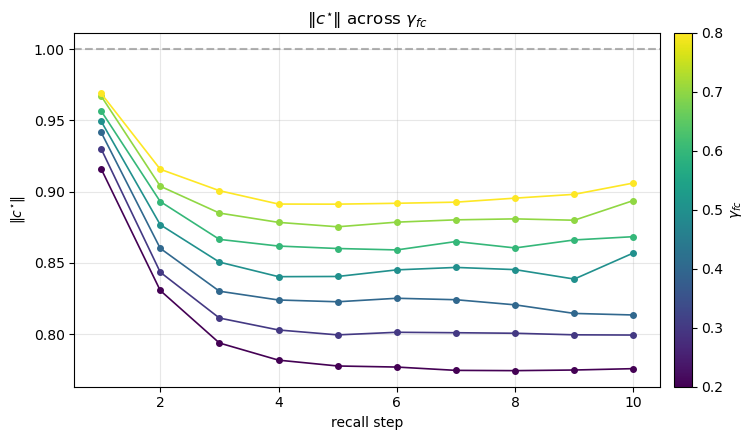

In [12]:
plot_context_gain_panel(
    cg_gamma_fc, gamma_fc_grid, "c_star_norm", r"$\gamma_{fc}$",
    title=r"$\|c^{\star}\|$ across $\gamma_{fc}$",
    ylabel=r"$\|c^{\star}\|$", ref_line=1.0)

### $\cos(c^{+}, \hat{c}_{in})$ post-update alignment

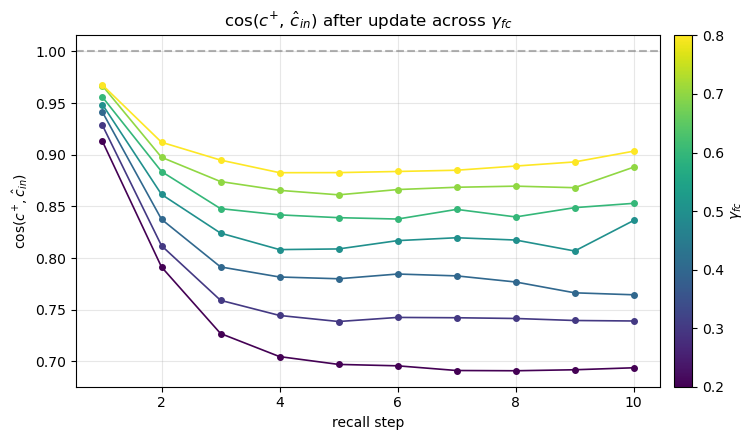

In [13]:
plot_context_gain_panel(
    cg_gamma_fc, gamma_fc_grid, "cos_c_cin", r"$\gamma_{fc}$",
    title=r"$\cos(c^{+},\,\hat{c}_{in})$ after update across $\gamma_{fc}$",
    ylabel=r"$\cos(c^{+}, \hat{c}_{in})$", ref_line=1.0)

### $c^{\top}\hat{c}_{in}$ pre-update alignment

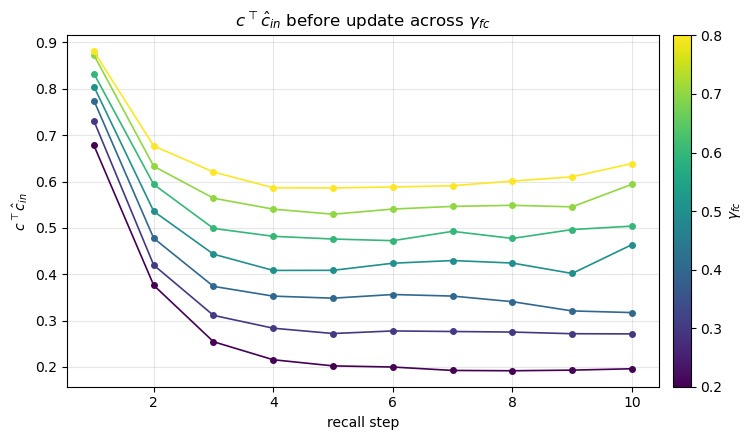

In [14]:
plot_context_gain_panel(
    cg_gamma_fc, gamma_fc_grid, "dot_before", r"$\gamma_{fc}$",
    title=r"$c^{\top}\hat{c}_{in}$ before update across $\gamma_{fc}$",
    ylabel=r"$c^{\top}\hat{c}_{in}$")

---
## 3. Sweep $\eta$ (accumulator noise)

Accumulator noise affects **which item wins** the retrieval competition, not
the context-update mechanism directly.  So:

* $\|c_{in}^{\text{raw}}\|$ and $\|c^{\star}\|$ should move **weakly** (only
  because a different winner has a different $M_{FC}$ column).
* $\cos(c, \hat{c}_{in})$ is the most **informative** trace here: if higher
  noise causes less-similar items to win, alignment should drop.

In [15]:
cg_eta = run_context_gain_sweep("eta", eta_grid, n_sims=n_sims)

  eta=0.1  done
  eta=0.2  done
  eta=0.3  done
  eta=0.4  done
  eta=0.5  done
  eta=0.6  done


### $\|c_{in}^{\text{raw}}\|$ raw context-input strength

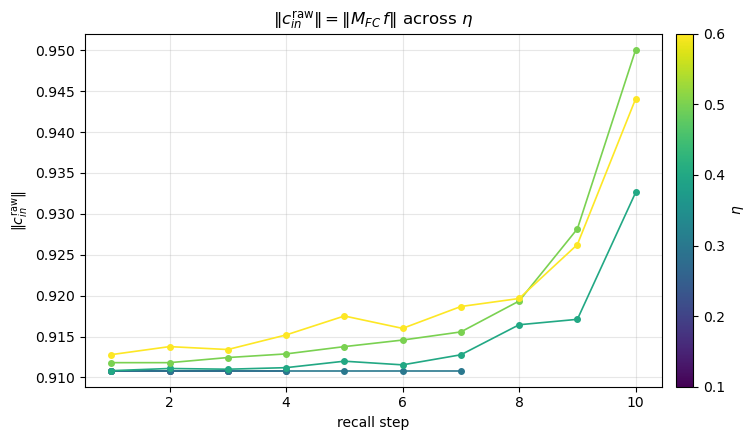

In [16]:
plot_context_gain_panel(
    cg_eta, eta_grid, "c_in_raw_norm", r"$\eta$",
    title=r"$\|c_{in}^{\mathrm{raw}}\| = \|M_{FC}\,f\|$ across $\eta$",
    ylabel=r"$\|c_{in}^{\mathrm{raw}}\|$")

### $\|c^{\star}\|$ pre-normalization update gain

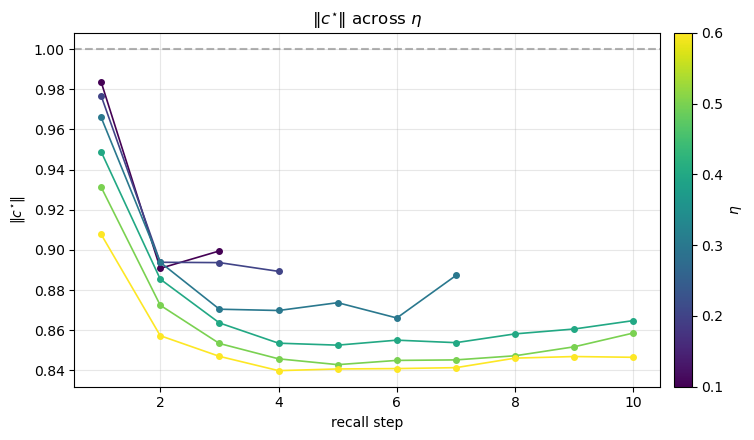

In [17]:
plot_context_gain_panel(
    cg_eta, eta_grid, "c_star_norm", r"$\eta$",
    title=r"$\|c^{\star}\|$ across $\eta$",
    ylabel=r"$\|c^{\star}\|$", ref_line=1.0)

### $\cos(c^{+}, \hat{c}_{in})$: which item wins changes alignment?

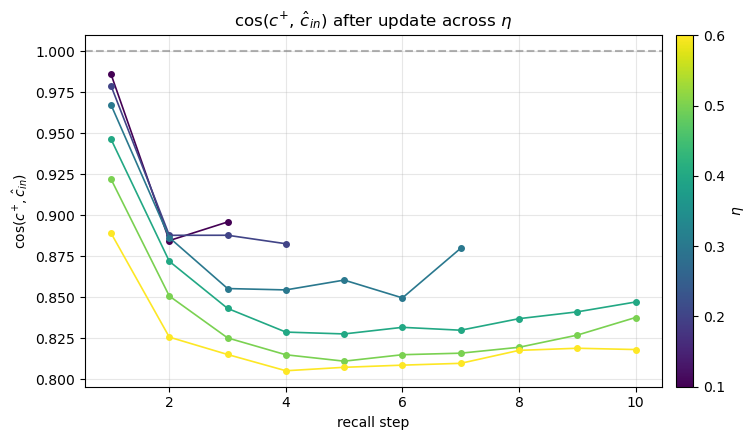

In [18]:
plot_context_gain_panel(
    cg_eta, eta_grid, "cos_c_cin", r"$\eta$",
    title=r"$\cos(c^{+},\,\hat{c}_{in})$ after update across $\eta$",
    ylabel=r"$\cos(c^{+}, \hat{c}_{in})$", ref_line=1.0)

### $c^{\top}\hat{c}_{in}$ pre-update dot product

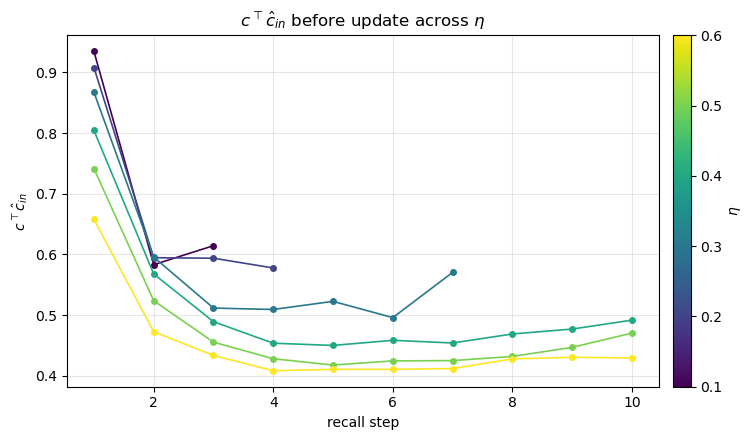

In [19]:
plot_context_gain_panel(
    cg_eta, eta_grid, "dot_before", r"$\eta$",
    title=r"$c^{\top}\hat{c}_{in}$ before update across $\eta$",
    ylabel=r"$c^{\top}\hat{c}_{in}$")

---
## 4. Sweep $B_{enc}$ scale (global encoding drift strength)

The encoding drift scale controls how strongly context drifts during study,
which in turn determines the structure of learned $M_{FC}$ weights.
Larger $B_{enc}$ produces stronger context transitions and larger $\|M_{FC}\,f\|$.

* $\|c_{in}^{\text{raw}}\|$ is **highly informative**: does scaling encoding
  actually increase the raw activation strength of $M_{FC}$?
* $\cos(c, \hat{c}_{in})$ tells you whether increased strength is
  **targeted** (high cosine) or **diffuse** (low cosine).

In [20]:
cg_B_enc = run_context_gain_sweep("B_encD_scale", B_encD_scale_grid, n_sims=n_sims)

  B_encD_scale=0.2  done
  B_encD_scale=0.4  done
  B_encD_scale=0.6  done
  B_encD_scale=0.8  done
  B_encD_scale=1  done


### $\|c_{in}^{\text{raw}}\|$: does encoding strength boost $M_{FC}$ activation?

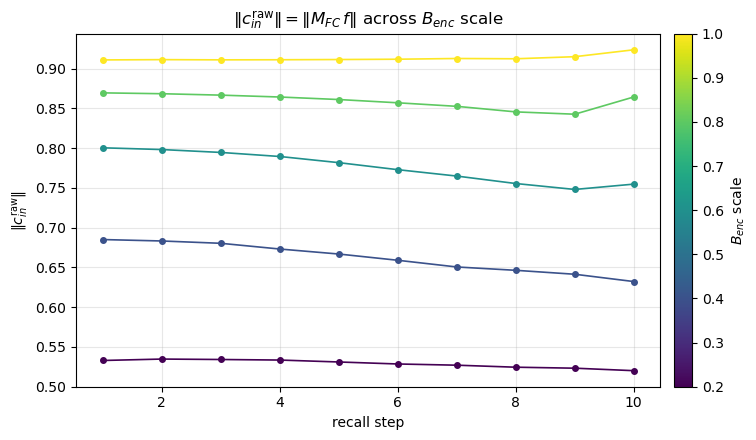

In [21]:
plot_context_gain_panel(
    cg_B_enc, B_encD_scale_grid, "c_in_raw_norm", r"$B_{enc}$ scale",
    title=r"$\|c_{in}^{\mathrm{raw}}\| = \|M_{FC}\,f\|$ across $B_{enc}$ scale",
    ylabel=r"$\|c_{in}^{\mathrm{raw}}\|$")

### $\|c^{\star}\|$ pre-normalization update gain

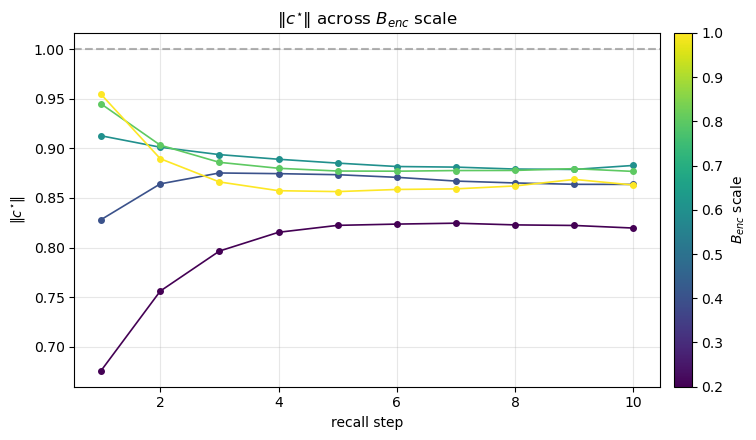

In [22]:
plot_context_gain_panel(
    cg_B_enc, B_encD_scale_grid, "c_star_norm", r"$B_{enc}$ scale",
    title=r"$\|c^{\star}\|$ across $B_{enc}$ scale",
    ylabel=r"$\|c^{\star}\|$", ref_line=1.0)

### $\cos(c^{+}, \hat{c}_{in})$ post-update alignment

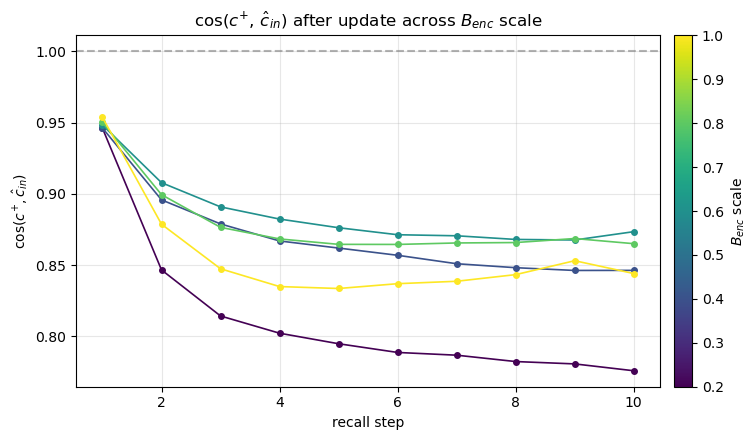

In [23]:
plot_context_gain_panel(
    cg_B_enc, B_encD_scale_grid, "cos_c_cin", r"$B_{enc}$ scale",
    title=r"$\cos(c^{+},\,\hat{c}_{in})$ after update across $B_{enc}$ scale",
    ylabel=r"$\cos(c^{+}, \hat{c}_{in})$", ref_line=1.0)

### $c^{\top}\hat{c}_{in}$ pre-update alignment

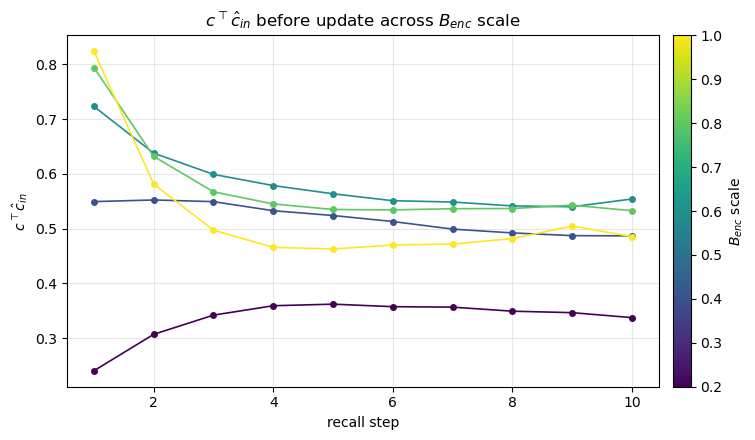

In [24]:
plot_context_gain_panel(
    cg_B_enc, B_encD_scale_grid, "dot_before", r"$B_{enc}$ scale",
    title=r"$c^{\top}\hat{c}_{in}$ before update across $B_{enc}$ scale",
    ylabel=r"$c^{\top}\hat{c}_{in}$")

---
## Cross-parameter comparison

Side-by-side $\|c_{in}^{\text{raw}}\|$ and $\|c^{\star}\|$ across all
four sweeps, to see which parameters move which quantity.

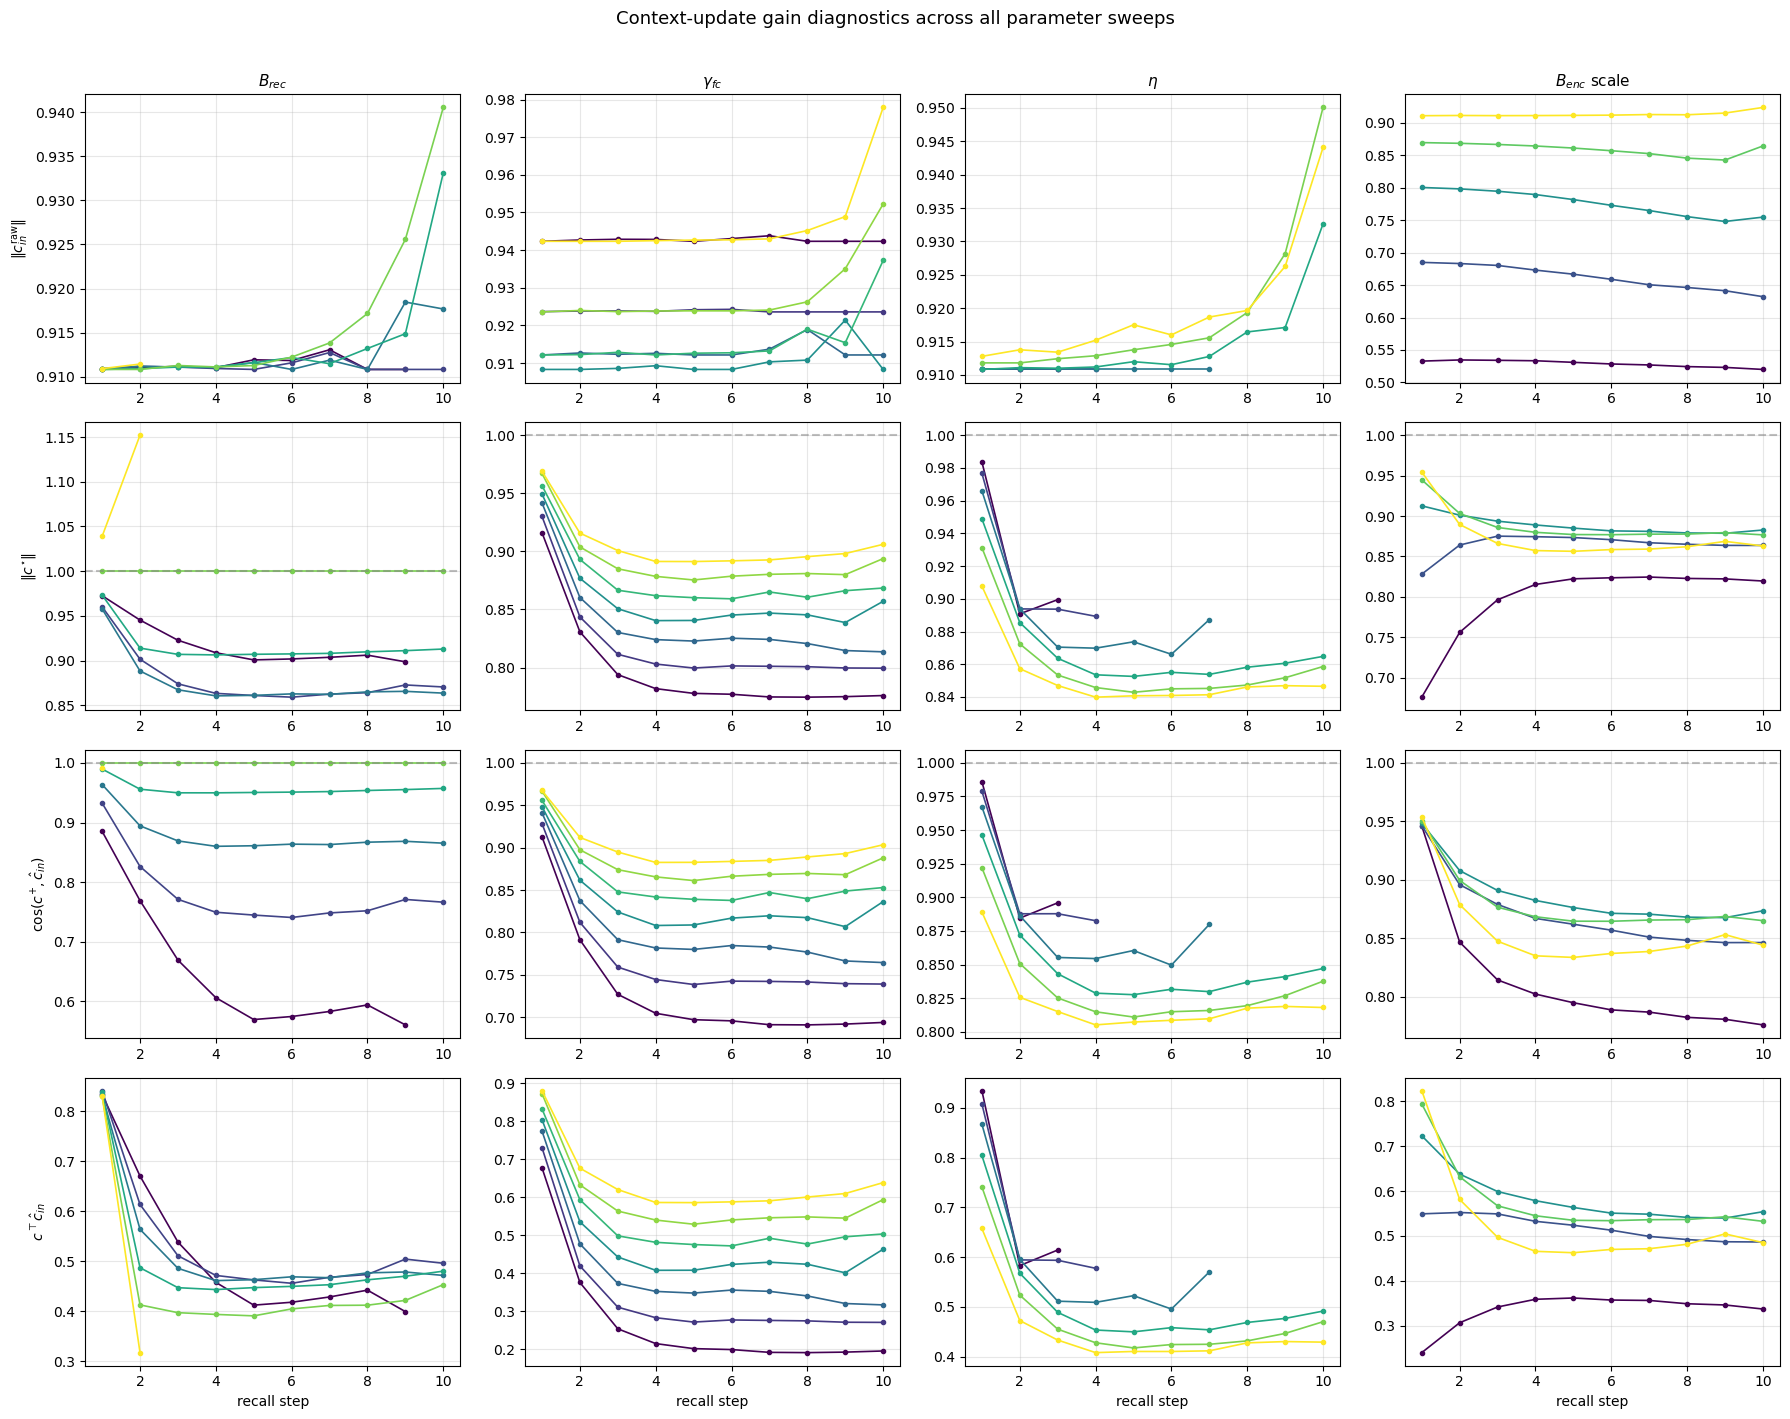

In [30]:
fig, axs = plt.subplots(4, 4, figsize=(18, 14), sharex=False)

fields = [
    ("c_in_raw_norm",  r"$\|c_{in}^{\mathrm{raw}}\|$"),
    ("c_star_norm",    r"$\|c^{\star}\|$"),
    ("cos_c_cin",      r"$\cos(c^{+}, \hat{c}_{in})$"),
    ("dot_before",     r"$c^{\top}\hat{c}_{in}$"),
]

sweeps = [
    (cg_B_rec,     B_rec_grid,        r"$B_{rec}$"),
    (cg_gamma_fc,  gamma_fc_grid,     r"$\gamma_{fc}$"),
    (cg_eta,       eta_grid,          r"$\eta$"),
    (cg_B_enc,     B_encD_scale_grid, r"$B_{enc}$ scale"),
]

for col, (res, grid, label) in enumerate(sweeps):
    grid = np.asarray(grid, dtype=float)
    colors, norm, cmap = make_sweep_colors(grid)

    for row, (field, ylabel) in enumerate(fields):
        ax = axs[row, col]
        for val, c in zip(grid, colors):
            x, y = res[val][field]
            if x.size:
                ax.plot(x, y, color=c, lw=1.2, ms=3, marker="o")
        if field in ("c_star_norm", "cos_c_cin"):
            ax.axhline(1, ls="--", color="gray", alpha=0.5)
        if row == 0:
            ax.set_title(label, fontsize=11)
        if row == 3:
            ax.set_xlabel("recall step")
        if col == 0:
            ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3)

fig.suptitle("Context-update gain diagnostics across all parameter sweeps", fontsize=13, y=1.01)
fig.tight_layout()
plt.show()